In [3]:
import pandas as pd

banksim = pd.read_csv("/Users/tejaljadhav/Desktop/UCD/Spring2026/Deep Learning/DL_Project/Dataset/bs140513_032310.csv")
banksim.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [4]:
banksim.shape

(594643, 10)

In [5]:
banksim.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  object 
 2   age          594643 non-null  object 
 3   gender       594643 non-null  object 
 4   zipcodeOri   594643 non-null  object 
 5   merchant     594643 non-null  object 
 6   zipMerchant  594643 non-null  object 
 7   category     594643 non-null  object 
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 45.4+ MB


In [6]:
banksim.describe()


,step,amount,fraud
count,594643.000000,594643.000000,594643.000000
mean,94.986827,37.890135,0.012108
std,51.053632,111.402831,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000


In [7]:
banksim.isnull().sum()

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64

In [8]:
banksim["fraud"].value_counts()


fraud
0    587443
1      7200
Name: count, dtype: int64

In [9]:
banksim["fraud"].value_counts(normalize=True) * 100


fraud
0    98.789189
1     1.210811
Name: proportion, dtype: float64

In [10]:
banksim.groupby("fraud")["amount"].describe()


,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,587443.0,31.847230,31.470876,0.00,13.59,26.610,41.8950,2144.86
1,7200.0,530.926551,835.587112,0.03,159.98,319.175,548.9775,8329.96


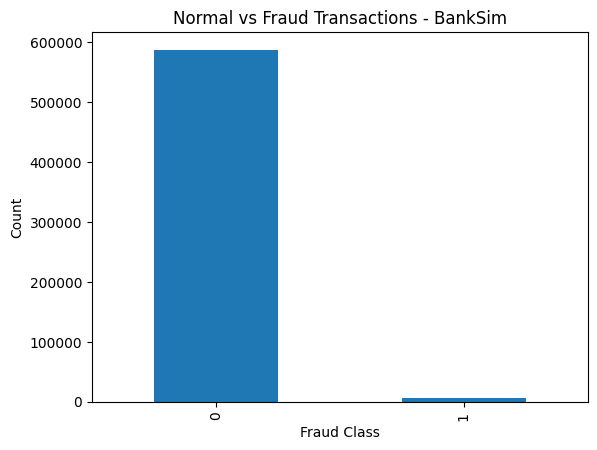

In [11]:
import matplotlib.pyplot as plt

banksim["fraud"].value_counts().plot(kind="bar")
plt.title("Normal vs Fraud Transactions - BankSim")
plt.xlabel("Fraud Class")
plt.ylabel("Count")
plt.show()


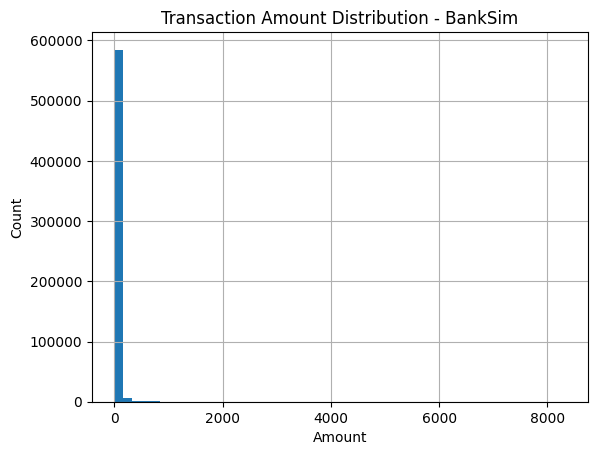

In [12]:
banksim["amount"].hist(bins=50)
plt.title("Transaction Amount Distribution - BankSim")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()


In [13]:
banksim["category"].value_counts()


category
'es_transportation'        505119
'es_food'                   26254
'es_health'                 16133
'es_wellnessandbeauty'      15086
'es_fashion'                 6454
'es_barsandrestaurants'      6373
'es_hyper'                   6098
'es_sportsandtoys'           4002
'es_tech'                    2370
'es_home'                    1986
'es_hotelservices'           1744
'es_otherservices'            912
'es_contents'                 885
'es_travel'                   728
'es_leisure'                  499
Name: count, dtype: int64

In [14]:
banksim.groupby("category")["fraud"].mean().sort_values(ascending=False)

category
'es_leisure'               0.949900
'es_travel'                0.793956
'es_sportsandtoys'         0.495252
'es_hotelservices'         0.314220
'es_otherservices'         0.250000
'es_home'                  0.152064
'es_health'                0.105126
'es_tech'                  0.066667
'es_wellnessandbeauty'     0.047594
'es_hyper'                 0.045917
'es_barsandrestaurants'    0.018829
'es_fashion'               0.017973
'es_contents'              0.000000
'es_food'                  0.000000
'es_transportation'        0.000000
Name: fraud, dtype: float64

In [15]:
banksim["gender"].value_counts()

gender
'F'    324565
'M'    268385
'E'      1178
'U'       515
Name: count, dtype: int64

In [16]:
banksim.groupby("gender")["fraud"].mean().sort_values(ascending=False)



gender
'F'    0.014660
'M'    0.009073
'E'    0.005942
'U'    0.000000
Name: fraud, dtype: float64

In [17]:
banksim["age"].value_counts().sort_index()


age
'0'      2452
'1'     58131
'2'    187310
'3'    147131
'4'    109025
'5'     62642
'6'     26774
'U'      1178
Name: count, dtype: int64

In [18]:
banksim.groupby("age")["fraud"].mean().sort_values(ascending=False)


age
'0'    0.019576
'4'    0.012933
'2'    0.012514
'3'    0.011928
'1'    0.011853
'5'    0.010951
'6'    0.009748
'U'    0.005942
Name: fraud, dtype: float64

In [19]:
banksim.groupby("merchant")["fraud"].mean().sort_values(ascending=False).head(10)


merchant
'M1294758098'    0.963351
'M3697346'       0.941558
'M1873032707'    0.864000
'M732195782'     0.851974
'M980657600'     0.832109
'M1353266412'    0.820513
'M857378720'     0.754098
'M2080407379'    0.750000
'M2011752106'    0.680328
'M17379832'      0.631206
Name: fraud, dtype: float64